In [39]:
import numpy as np 
import h5py
import matplotlib.pyplot as plt 
import copy 
import time
import scipy
from PIL import Image
from scipy import ndimage

np.random.seed(1)

In [40]:
def initialize_parameters(n_x, n_h, n_y):
    W1 = np.random.randn(n_h, n_x)*0.01
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h)*0.01
    b2 = np.zeros((n_y, 1))

    parameters = {"W1": W1, 
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}

    return parameters

In [85]:
def initialize_parameters_deep(layer_dims):
    np.random.seed(1)
    parameters = {}
    L = len(layer_dims)            

    for l in range(1, L):
        parameters['W' + str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1]) / np.sqrt(layer_dims[l-1]) #*0.01
        parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))
        
        assert(parameters['W' + str(l)].shape == (layer_dims[l], layer_dims[l-1]))
        assert(parameters['b' + str(l)].shape == (layer_dims[l], 1))

        
    return parameters

In [70]:
print("Test case 1: \n")
parameters = initialize_parameters_deep([5, 4, 5, 3])

print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))
print("W3 = " + str(parameters["W3"]))
print("b3 = " + str(parameters["b3"]))

Test case 1: 

W1 = [[-0.01762613 -0.00196196  0.01106222 -0.00039014 -0.00678872]
 [ 0.00668668 -0.0144448   0.01711598 -0.00675807 -0.0055767 ]
 [-0.009273    0.02977083 -0.00031197 -0.00385059  0.00322975]
 [ 0.01251167 -0.02236985 -0.00608458 -0.00045589 -0.01244652]]
b1 = [[0.]
 [0.]
 [0.]
 [0.]]
W2 = [[ 0.00632144  0.00645102  0.00217773  0.01514769]
 [-0.00492024 -0.00173148 -0.01389835  0.00749319]
 [-0.00974252 -0.00429384  0.00447299  0.01202409]
 [ 0.01029981 -0.00599744 -0.01083745 -0.01578686]
 [ 0.01088413  0.00944261 -0.00179448 -0.01387623]]
b2 = [[0.]
 [0.]
 [0.]
 [0.]
 [0.]]
W3 = [[-0.01433551 -0.00352996 -0.00206925 -0.02025282  0.014832  ]
 [ 0.00187727  0.00125442 -0.00597202 -0.00030337  0.00832469]
 [ 0.0076064  -0.00856447  0.00826006  0.00018375  0.00143737]]
b3 = [[0.]
 [0.]
 [0.]]


In [43]:
def linear_forward(A, W, b):
    Z = np.dot(W, A) + b
    cache = (A, W, b)

    return Z, cache

In [44]:
def sigmoid(Z):
    A = 1/(1 + np.exp(-Z))
    cache = Z

    return A, cache

In [45]:
def relu(Z):
    A = np.maximum(0, Z)

    assert(A.shape == Z.shape)
    cache = Z

    return A, cache

In [46]:
def linear_activation_forward(A_prev, W, b, activation):
    if activation == "sigmoid":
        Z, linear_cache = linear_forward(A_prev, W, b)
        A, activation_cache = sigmoid(Z)

    elif activation == "relu":
        Z, linear_cache = linear_forward(A_prev, W, b)
        A, activation_cache = relu(Z)

    cache = (linear_cache, activation_cache)

    return A, cache

In [47]:
def L_model_forward(X, parameters):
    caches = []
    A = X
    L = len(parameters)//2

    for l in range(1, L):
        A_prev = A
        A, cache = linear_activation_forward(
            A_prev, 
            parameters['W' + str(l)],
            parameters['b' + str(l)],
            activation="relu"
        )

        caches.append(cache)

    AL, cache = linear_activation_forward(
        A,
        parameters['W' + str(L)],
        parameters['b' + str(L)],
        activation="sigmoid"
    )

    caches.append(cache)

    return AL, caches

In [48]:
def compute_cost(AL, Y):
    m = Y.shape[1]
    cost = -1/m*(
        np.dot(Y, np.log(AL + 1e-8).T) +
        np.dot(1-Y, np.log(1-AL + 1e-8).T)
    )

    cost = np.squeeze(cost)

    return cost

In [49]:
def linear_backward(dZ, cache):
    A_prev, W, b = cache
    m = A_prev.shape[1]

    dW = 1/m*(np.dot(dZ, A_prev.T))
    db = 1/m*np.sum(dZ, axis = 1, keepdims = True)
    dA_prev = np.dot(W.T, dZ)

    return dA_prev, dW, db

In [50]:
def relu_backward(dA, cache):
    Z = cache
    dZ = np.array(dA, copy=True) 
    
    dZ[Z <= 0] = 0
    
    assert (dZ.shape == Z.shape)
    
    return dZ

In [51]:
def sigmoid_backward(dA, cache):
    Z = cache
    
    s = 1/(1+np.exp(-Z))
    dZ = dA * s * (1-s)
    
    assert (dZ.shape == Z.shape)
    
    return dZ


In [52]:
def linear_activation_backward(dA, cache, activation):
    linear_cache, activation_cache = cache

    if activation=="relu":
        dZ = relu_backward(dA, activation_cache)
        dA_prev, dW, db = linear_backward(dZ, linear_cache)

    elif activation=="sigmoid":
        dZ = sigmoid_backward(dA, activation_cache)
        dA_prev, dW, db = linear_backward(dZ, linear_cache)

    return dA_prev, dW, db

In [ ]:
def L_model_backward(AL, Y, caches):
    grads = {}
    L = len(caches)
    m = AL.shape[1]
    Y = Y.reshape(AL.shape)

    dAL = -(np.divide(Y, AL + 1e-8) - np.divide(1 - Y, 1 - AL + 1e-8))

    current_cache = caches[L - 1]

    dA_prev_temp, dW_temp, db_temp = linear_activation_backward(
    dAL,
    current_cache,
    activation="sigmoid"
    )
    
    grads["dA" + str(L - 1)] = dA_prev_temp
    grads["dW" + str(L)] = dW_temp
    grads["db" + str(L)] = db_temp

    for l in reversed(range(L-1)):
        current_cache = caches[l]

        dA_prev_temp, dW_temp, db_temp = linear_activation_backward(
            grads["dA" + str(l + 1)],
            current_cache,
            activation="relu"
        )

        grads["dA" + str(l)] = dA_prev_temp
        grads["dW" + str(l + 1)] = dW_temp
        grads["db" + str(l + 1)] = db_temp

    return grads

In [54]:
def update_parameters(params, grads, learning_rate):
    parameters = copy.deepcopy(params)
    L = len(parameters)//2

    for l in range(L):
        parameters["W" + str(l + 1)] = parameters["W" + str(l + 1)] - learning_rate*grads["dW" + str(l + 1)]

        parameters["b" + str(l + 1)] = parameters["b" + str(l + 1)] - learning_rate*grads["db" + str(l + 1)]
        
    return parameters

In [55]:
def predict(X, y, parameters):
    m = X.shape[1]
    n = len(parameters) // 2 
    p = np.zeros((1,m))
    
    probas, caches = L_model_forward(X, parameters)

    for i in range(0, probas.shape[1]):
        if probas[0,i] > 0.5:
            p[0,i] = 1
        else:
            p[0,i] = 0
    
    print("Accuracy: "  + str(np.sum(p == y)/m))
        
    return p

## We will implement this the deep neural network on the cat data

In [56]:
def load_data():
    train_dataset = h5py.File('../Datasets/train_catvnoncat.h5', "r")
    train_set_x_orig = np.array(train_dataset["train_set_x"][:]) # your train set features
    train_set_y_orig = np.array(train_dataset["train_set_y"][:]) # your train set labels

    test_dataset = h5py.File('../Datasets/test_catvnoncat.h5', "r")
    test_set_x_orig = np.array(test_dataset["test_set_x"][:]) # your test set features
    test_set_y_orig = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes
    
    train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
    test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))
    
    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes


In [57]:
train_x_orig, train_y, test_x_orig, test_y, classes = load_data()

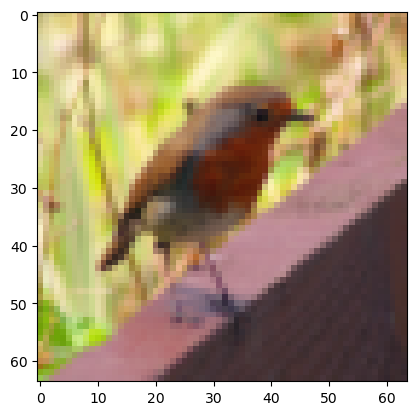

In [58]:
index = 10
plt.imshow(train_x_orig[index])

In [59]:
m_train = train_x_orig.shape[0]
num_px = train_x_orig.shape[1]
m_test = test_x_orig.shape[0]

print ("Number of training examples: " + str(m_train))
print ("Number of testing examples: " + str(m_test))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_x_orig shape: " + str(train_x_orig.shape))
print ("train_y shape: " + str(train_y.shape))
print ("test_x_orig shape: " + str(test_x_orig.shape))
print ("test_y shape: " + str(test_y.shape))

Number of training examples: 209
Number of testing examples: 50
Each image is of size: (64, 64, 3)
train_x_orig shape: (209, 64, 64, 3)
train_y shape: (1, 209)
test_x_orig shape: (50, 64, 64, 3)
test_y shape: (1, 50)


In [60]:
train_x_flatten = train_x_orig.reshape(train_x_orig.shape[0], -1).T   
test_x_flatten = test_x_orig.reshape(test_x_orig.shape[0], -1).T

In [61]:
train_x = train_x_flatten/255.
test_x = test_x_flatten/255.

print ("train_x's shape: " + str(train_x.shape))
print ("test_x's shape: " + str(test_x.shape))

train_x's shape: (12288, 209)
test_x's shape: (12288, 50)


In [24]:
n_x = 12288
n_h = 7
n_y = 1
layer_dims = (n_x, n_h, n_y)
learning_rate = 0.0075

In [25]:
def two_layer_model(X, Y, layers_dims, learning_rate = 0.0075, num_iterations = 3000, print_cost = False):
    np.random.seed(1)
    grads = {}
    costs = []
    m = X.shape[1]
    (n_x, n_h, n_y) = layer_dims

    parameters = initialize_parameters(n_x, n_h, n_y)

    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    
    for i in range(0, num_iterations):
        A1, cache1 = linear_activation_forward(X, W1, b1, activation="relu")
        A2, cache2 = linear_activation_forward(A1, W2, b2, activation="sigmoid")

        cost = compute_cost(A2, Y)

        dA2 = - (np.divide(Y, A2) - np.divide(1 - Y, 1 - A2))

        dA1, dW2, db2 = linear_activation_backward(
        dA2,
        cache2,
        activation="sigmoid"
        )

        dA0, dW1, db1 = linear_activation_backward(
            dA1,
            cache1,
            activation="relu"
        )

        grads['dW1'] = dW1
        grads['db1'] = db1
        grads['dW2'] = dW2
        grads['db2'] = db2
        
        parameters = update_parameters(parameters, grads, learning_rate)

        W1 = parameters["W1"]
        b1 = parameters["b1"]
        W2 = parameters["W2"]
        b2 = parameters["b2"]

        if print_cost and (i % 100 == 0 or i == num_iterations - 1):
            print("Cost after iteration {}: {}".format(i, np.squeeze(cost)))
        if i % 100 == 0:
            costs.append(cost)

    return parameters, costs

def plot_costs(costs, learning_rate=0.0075):
    plt.plot(np.squeeze(costs))
    plt.ylabel('cost')
    plt.xlabel('iterations (per hundreds)')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()

Cost after iteration 0: 0.6930497156618451


Cost after iteration 100: 0.6464320754278845
Cost after iteration 200: 0.6325140451322062
Cost after iteration 300: 0.6015024729661067
Cost after iteration 400: 0.5601966126878601
Cost after iteration 500: 0.5158304595151496
Cost after iteration 600: 0.47549011406707264
Cost after iteration 700: 0.4339162984376415
Cost after iteration 800: 0.40079773710446237
Cost after iteration 900: 0.35807048529896635
Cost after iteration 1000: 0.3394281380542095
Cost after iteration 1100: 0.305275348523883
Cost after iteration 1200: 0.2749137583577553
Cost after iteration 1300: 0.2468176682359081
Cost after iteration 1400: 0.19850733750375377
Cost after iteration 1500: 0.17448316868299588
Cost after iteration 1600: 0.1708076173546982
Cost after iteration 1700: 0.11306523414870508
Cost after iteration 1800: 0.09629425723333504
Cost after iteration 1900: 0.08342616854593193
Cost after iteration 2000: 0.07439077612975831
Cost after iteration 2100: 0.06630747052537361
Cost after iteration 2200: 0.05919

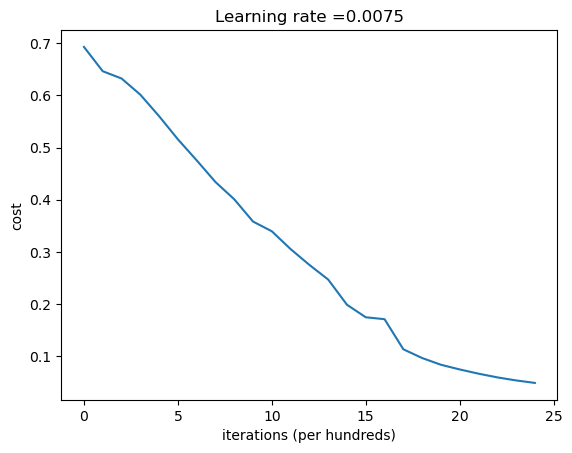

In [84]:
parameters, costs = two_layer_model(train_x, train_y, layers_dims = (n_x, n_h, n_y), num_iterations = 2500, print_cost=True)
plot_costs(costs, learning_rate)

In [27]:
predictions_train = predict(train_x, train_y, parameters)

Accuracy: 1.0


In [28]:
predictions_test = predict(test_x, test_y, parameters)

Accuracy: 0.72


### Using a L-layer neural network

In [101]:
layers_dims = [12288, 20, 7, 5, 1] 

In [102]:
def L_layer_model(X, Y, layers_dims, learning_rate = 0.0075, num_iterations = 3000, print_cost=False):

    np.random.seed(1)
    costs = []                       
    parameters = initialize_parameters_deep(layers_dims)

    for i in range(0, num_iterations):

        AL, caches = L_model_forward(X, parameters)
        cost = compute_cost(AL, Y)
        grads = L_model_backward(AL, Y, caches)
        parameters = update_parameters(parameters, grads, learning_rate)
      
        if print_cost and (i % 100 == 0 or i == num_iterations - 1):
            print("Cost after iteration {}: {}".format(i, np.squeeze(cost)))
        if i % 100 == 0:
            costs.append(cost)
    
    return parameters, costs

In [103]:
parameters, costs = L_layer_model(train_x, train_y, layers_dims, num_iterations = 1, print_cost = False)

print("Cost after first iteration: " + str(costs[0]))


Cost after first iteration: 0.7717493063845895


In [104]:
parameters, costs = L_layer_model(train_x, train_y, layers_dims, num_iterations = 2500, print_cost = True)

Cost after iteration 0: 0.7717493063845895
Cost after iteration 100: 0.6720534204705266
Cost after iteration 200: 0.6482631856397857
Cost after iteration 300: 0.6115068630179431
Cost after iteration 400: 0.5670473089653184
Cost after iteration 500: 0.5401376459532466
Cost after iteration 600: 0.5279299395472773
Cost after iteration 700: 0.46547736078737667
Cost after iteration 800: 0.3691258377127101
Cost after iteration 900: 0.3917469589920164
Cost after iteration 1000: 0.3151869747671411
Cost after iteration 1100: 0.27269983067629094
Cost after iteration 1200: 0.23741852095979293
Cost after iteration 1300: 0.19960119276698124
Cost after iteration 1400: 0.189262991432559
Cost after iteration 1500: 0.1611885345080354
Cost after iteration 1600: 0.14821388458370974
Cost after iteration 1700: 0.13777486616798618
Cost after iteration 1800: 0.1297401635861958
Cost after iteration 1900: 0.12122533882201603
Cost after iteration 2000: 0.11382059486130289
Cost after iteration 2100: 0.1078392734

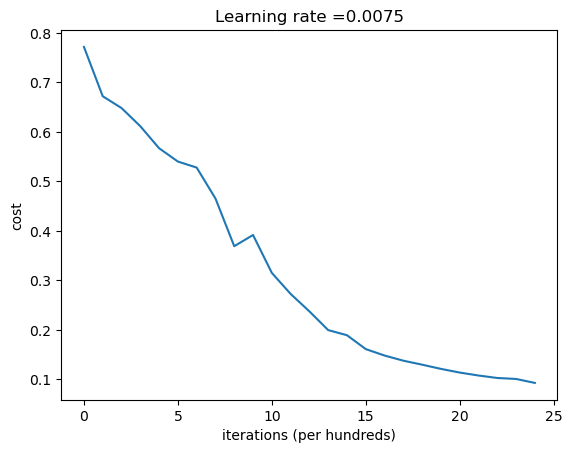

In [105]:
plot_costs(costs, learning_rate)

In [106]:
pred_train = predict(train_x, train_y, parameters)

Accuracy: 0.9856459330143541


In [107]:
pred_test = predict(test_x, test_y, parameters)

Accuracy: 0.8
